# Testing OT on Single Cell Data
Exact OT seems to work on single cell data. Now, we'll examine the performance on a subset of the single cell data. For this, we will first subset the data based on the metadata, then compute the SCCs of the first chromosome for this data, and finally compute exact OT loss and compare this.

## Importing and Subsetting

In [1]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
from time import perf_counter
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, scc_compare_matrix, bin_contact_map, fetch_region, get_cool_name, hic_ot_source_to_targets, compare_to_scc

In [ ]:
### Importing Data ###
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_scc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_scc_chr1'

# Metadata
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
cd4_metadata = metadata[metadata["cell_type"] == "CD4+ T cells"]
subset = list(cd4_metadata["cell_name"])[0:50]

# Importing CD4+ T cells
cd4_clrs = import_cool_dir(sc_dir, include=subset)

## Calculating SCC and Saving

In [16]:
### Performing SCC ###
cd4_scc_chr1 = scc_compare_matrix(cd4_clrs, 0, -1, False, ["chr1"])

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

In [19]:
### Saving Data ###
cd4_scc_chr1.to_csv(f'{save_scc_dir}/cd4_t_cell_chr1_scc.csv')
cd4_scc_chr1_help = pd.read_csv(f'{save_scc_dir}/cd4_t_cell_chr1_scc.csv', index_col=0)
cd4_scc_chr1_help

,arc_pair_20032,arc_pair_5350,arc_pair_18299,arc_pair_4279,arc_pair_18,arc_pair_12155,arc_pair_17547,arc_pair_5844,arc_pair_5055,arc_pair_11919,...,arc_pair_3868,arc_pair_194,arc_pair_9469,arc_pair_9687,arc_pair_20196,arc_pair_14061,arc_pair_5220,arc_pair_13337,arc_pair_1613,arc_pair_10940
arc_pair_20032,0.986961,0.614093,0.723393,0.699024,0.716759,0.725753,0.638752,0.685090,0.654908,0.540662,...,0.442836,0.700533,0.707033,0.669887,0.761981,0.655402,0.672967,0.672021,0.620275,0.611772
arc_pair_5350,0.614093,0.993461,0.490014,0.548480,0.614719,0.579050,0.505735,0.606260,0.622654,0.425489,...,0.432618,0.577896,0.622152,0.564164,0.654503,0.525698,0.539649,0.594196,0.510552,0.578990
arc_pair_18299,0.723393,0.490014,0.988256,0.806363,0.645689,0.570498,0.577692,0.606801,0.561698,0.511747,...,0.394327,0.640054,0.740667,0.612462,0.684918,0.714865,0.714734,0.684512,0.548292,0.529152
arc_pair_4279,0.699024,0.548480,0.806363,0.992013,0.648162,0.586935,0.553561,0.616457,0.574881,0.491338,...,0.390739,0.638465,0.788610,0.592425,0.722913,0.735138,0.671233,0.674334,0.553645,0.546083
arc_pair_18,0.716759,0.614719,0.645689,0.648162,0.991560,0.691726,0.641758,0.656962,0.635098,0.525355,...,0.408091,0.604943,0.637312,0.630080,0.712406,0.641566,0.662776,0.709349,0.599350,0.601463
arc_pair_12155,0.725753,0.579050,0.570498,0.586935,0.691726,0.987606,0.619978,0.605005,0.621477,0.481582,...,0.410552,0.623819,0.620133,0.570973,0.692118,0.603861,0.571676,0.589406,0.541235,0.548486
arc_pair_17547,0.638752,0.505735,0.577692,0.553561,0.641758,0.619978,0.994655,0.613091,0.569233,0.496067,...,0.439770,0.593083,0.605166,0.591766,0.680039,0.609817,0.685290,0.615058,0.568624,0.594464
arc_pair_5844,0.685090,0.606260,0.606801,0.616457,0.656962,0.605005,0.613091,0.986730,0.647872,0.535082,...,0.460940,0.674642,0.664543,0.652101,0.790066,0.606126,0.667055,0.640854,0.591323,0.640410
arc_pair_5055,0.654908,0.622654,0.561698,0.574881,0.635098,0.621477,0.569233,0.647872,0.989864,0.546870,...,0.435565,0.619460,0.588433,0.602576,0.712088,0.611831,0.565766,0.600748,0.520018,0.559706
arc_pair_11919,0.540662,0.425489,0.511747,0.491338,0.525355,0.481582,0.496067,0.535082,0.546870,0.965253,...,0.367934,0.507197,0.510456,0.516829,0.570643,0.505893,0.546208,0.542896,0.391431,0.440094


## Exact OT

In [7]:
### Getting chr1 and binning ###
# Extracting chromosome 1
cd4_chr1s = []
map_names = []

for clr in cd4_clrs:
    cd4_chr1s.append(fetch_region(clr, 'chr1'))
    map_names.append(get_cool_name(clr).split("_")[2])

# Binning to 8 mb
cd4_binned_8mb = []
for chr1 in cd4_chr1s:
    cd4_binned_8mb.append(bin_contact_map(chr1, 8))

In [8]:
### Exact OT ###
ot_results_list = []
start_time = perf_counter()
for map in cd4_binned_8mb:
    ot_results_list.append(hic_ot_source_to_targets(map, cd4_binned_8mb, 0, "raw", "sum"))
end_time = perf_counter()
calc_time = end_time - start_time

## Calculating R2 values

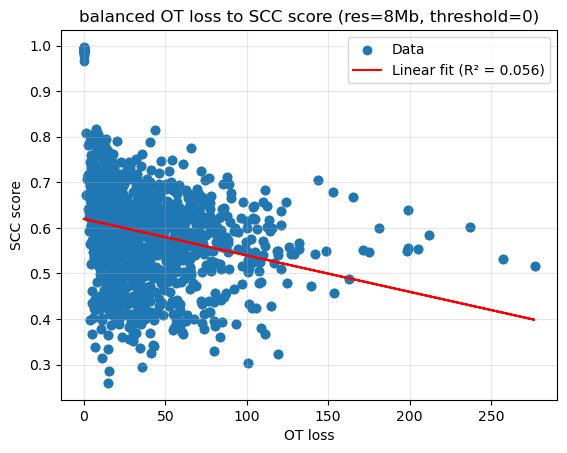

In [9]:
### Calculating R2 values between scc and OT and plotting ###
scc_ot_cd4_df, scc_cd4_r2 = compare_to_scc(ot_results_list, map_names, cd4_scc_chr1,
                                               0, 8, plot = True)

# Saving results
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_ot_chr1/balanced_8mb_0_cd4_t_chr1.csv'
scc_ot_cd4_df.to_csv(save_dir)